In [1]:
from kan import KAN, create_dataset
import torch
from torch.utils.data import DataLoader, TensorDataset
from MLP2layers import NeuralNetwork, test_loop, train_loop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
from torch import nn

OrderedDict({'linear_relu_stack.0.weight': tensor([[0.7219],
        [0.7200],
        [0.4736]]), 'linear_relu_stack.0.bias': tensor([-0.0391,  0.9502, -0.3808]), 'linear_relu_stack.2.weight': tensor([[-0.4798,  0.1497,  0.4314]]), 'linear_relu_stack.2.bias': tensor([-0.3649])})
checkpoint directory created: ./model
saving model version 0.0
[Linear(in_features=1, out_features=3, bias=True)]
weight: tensor([[0.7219, 0.7200, 0.4736]], grad_fn=<SliceBackward0>), bias: tensor([[-0.0391,  0.9502, -0.3808]], grad_fn=<SliceBackward0>)
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]
weight: tensor([[-0.4798]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1216]], grad_fn=<SliceBackward0>)
weight: tensor([[0.1497]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1216]], grad_fn=<SliceBackward0>)
weight: tensor([[0.4314]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1216]], grad_fn=<SliceBackward0>)


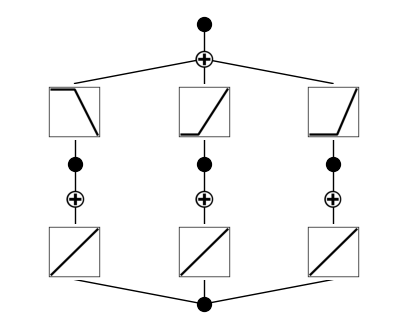

In [2]:
device = 'cpu'
targetModel = NeuralNetwork(input_size=1).to(device)
layers = list(*targetModel.children())
x = torch.linspace(-5,5,steps=500)[:,None].repeat(1,2)
print(targetModel.state_dict())

kan = KAN(width=[1,3,1], seed=42, grid=100, scale_base_sigma=0)
kan.set_splines(x, modelPartitions=[layers[:1], layers[1:]])
kan.plot(beta=100)

In [3]:
X_kan = torch.randn(10000,1)
y_kan = targetModel(X_kan).detach()
y_kan_mean = y_kan.numpy().mean()

In [4]:
train_dataset = TensorDataset(X_kan, y_kan)
test_dataset = TensorDataset(X_kan, y_kan)

train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cpu"

model = NeuralNetwork(input_size=1).to(device)
print(model)
print(model.state_dict())
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)


epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataLoader, model, loss_fn, optimizer)
    test_loop(test_dataLoader, model, loss_fn)


NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)
OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.7845],
        [-0.5528],
        [ 0.2748]]), 'linear_relu_stack.0.bias': tensor([-0.0559, -0.6386,  0.3391]), 'linear_relu_stack.2.weight': tensor([[ 0.4007, -0.5674,  0.5415]]), 'linear_relu_stack.2.bias': tensor([0.3187])})
Epoch 1
-------------------------------
Test loss: 0.006024
Epoch 2
-------------------------------
Test loss: 0.004575
Epoch 3
-------------------------------
Test loss: 0.003860
Epoch 4
-------------------------------
Test loss: 0.003289
Epoch 5
-------------------------------
Test loss: 0.002770
Epoch 6
-------------------------------
Test loss: 0.002305
Epoch 7
-------------------------------
Test loss: 0.001901
Epoch 8
-------------------------------
Test loss: 0.001555
Epoch 9
-------------------------------
Test loss

In [5]:
model.eval()
y_mlp_pred = model(X_kan).detach()
print(mean_squared_error(y_kan.numpy(), y_mlp_pred.numpy()))

0.00010010420373873785


checkpoint directory created: ./model
saving model version 0.0
[Linear(in_features=1, out_features=3, bias=True)]
weight: tensor([[-0.5508, -0.7782, -0.3758]], grad_fn=<SliceBackward0>), bias: tensor([[-0.4265,  0.0159,  0.3479]], grad_fn=<SliceBackward0>)
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]
weight: tensor([[0.1659]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1395]], grad_fn=<SliceBackward0>)
weight: tensor([[-0.4629]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1395]], grad_fn=<SliceBackward0>)
weight: tensor([[0.6034]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1395]], grad_fn=<SliceBackward0>)
0.00010005458898376673
0.00031003702


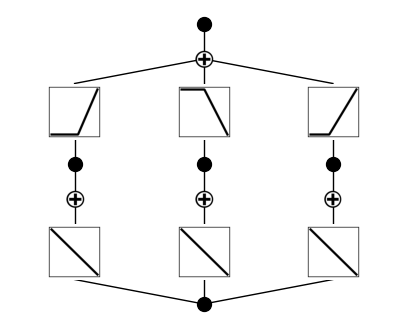

In [6]:
new_layers = list(*model.children())
kan2 = KAN(width=[1,3,1], seed=42, grid=100, scale_base_sigma=0)
kan2.set_splines(x, modelPartitions=[new_layers[:1], new_layers[1:]])
kan2.plot(beta=100)
y_kan2_pred = kan2(X_kan).detach()
kan2_mse = mean_squared_error(y_kan.numpy(), y_kan2_pred.numpy())   
print(kan2_mse)
print(abs(kan2_mse/y_kan_mean))

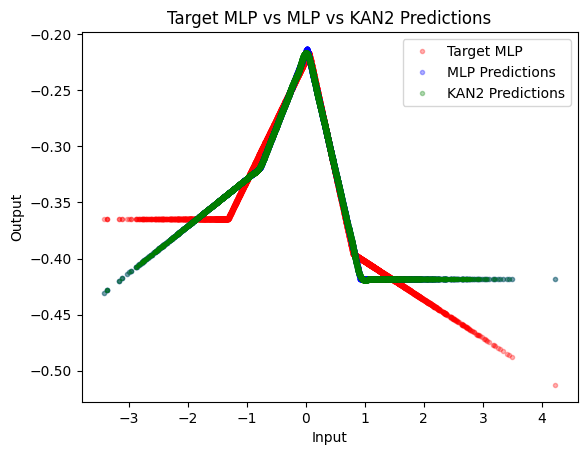

In [7]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D

# Get predictions from both models
X_plot = X_kan.numpy()
y_plot = y_kan.numpy()
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_plot).float()
    
    y_target_mlp_np = y_plot.flatten()

    y_mlp_pred_np = y_mlp_pred.numpy().flatten()
    y_kan2_pred_np = y_kan2_pred.numpy().flatten()

plt.plot(X_plot, y_target_mlp_np, 'r.', label='Target MLP', alpha=0.3)
plt.plot(X_plot, y_mlp_pred_np, 'b.', label='MLP Predictions', alpha=0.3)
plt.plot(X_plot, y_kan2_pred_np, 'g.', label='KAN2 Predictions', alpha=0.3)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Target MLP vs MLP vs KAN2 Predictions')
plt.legend()
plt.show()


# Use triangulation for scattered data (no griddata)
# triang = mtri.Triangulation(X_plot[:, 0], X_plot[:, 1])

# elevation = 30  # vertical angle
# for t in range(0, 360, 45):
#     azimuth = t
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     # ax.plot_trisurf(triang, y_target_mlp_np, cmap='Reds', alpha=0.6)
#     ax.plot_trisurf(triang, y_mlp_pred_np, cmap='Blues', alpha=0.6)
#     ax.plot_trisurf(triang, y_kan2_pred_np, cmap='Greens', alpha=0.6)
#     # ax.plot_trisurf(triang, y_kan2_pred_afterFit_np, cmap='Purples', alpha=0.6)
#     ax.set_xlabel('X_test[:, 0]')
#     ax.set_ylabel('X_test[:, 1]')
#     ax.set_zlabel('Output')
#     ax.set_title('Target MLP vs MLP vs KAN2 Predictions')
#     ax.view_init(elev=elevation, azim=azimuth)

#     # Create custom legend
#     legend_elements = [
#         Line2D([0], [0], color='blue', lw=4, label='MLP'),
#         Line2D([0], [0], color='green', lw=4, label='KAN2 Before Training'),
#     ]
#     ax.legend(handles=legend_elements, loc='upper right')

#     plt.show()
